# Multi-Agent Multi-Armed Bandits: 
## application to EVs smart charging with grid constraints

In [1]:
from matplotlib import pyplot as plt
from simulation.simulation import *
from utils.plot_analysis import *
from utils.strategy_comparison import *
from strategies import *
from tqdm.notebook import tqdm


Strategy.register("GREEDY", Baseline)
Strategy.register("PRIOR OPT", PriorOpt)
Strategy.register("Inde-TS", MABTS)
Strategy.register("FTPL-IRS-F2", MABFTPL)
Strategy.register("FTPL-IRS-EXP", MABFTPL)
Strategy.register("FTPL-IRS", MABFTPL)
Strategy.register("MILP_Price_Forecast", MilpForecastPrice)
Strategy.register("EV_DRL",DRL)



## Define base simulation parameters

In [2]:
# 
# num_ev_agents = np.array([30,60,120,240,480,960])

num_ev_agents = np.array([5])
num_nf_agents = (num_ev_agents * 2) / 3   # Number of Flexible agents

congestion_limits = (173000.0 / 30.0)*num_ev_agents  # 173000 for 30 EV agent [Reference ?]
pv_areas = (3000.0 / 30.0)*num_ev_agents # similated based on area [PV rating?]

num_sim_config = len(num_ev_agents)

num_episodes = 1460 # January 2021 - January 2024  # what is number of episodes

centralized_strategies_ca = ["MILP", "MILP_Price_Forecast"]
decentralized_strategies_ca =["FTPL-IRS-EXP", "FTPL-IRS-F2", "Inde-TS"]
decentralized_strategies = ["FTPL-IRS-EXP", "FTPL-IRS-F2", "Inde-TS", "GREEDY"]
test = ['GREEDY','EV_DRL']
num_samples = 10
base_path = "results_ECML2026/"

In [5]:
simulation_config_base_dict = {
    "T_episode_seconds": 24 * 60 * 60,  # 24 hours
    "dt": 15 * 60,  # 15 minutes
    "num_ev_agents": 5,  # Number of EV agents    # what is the difference between above num_ev_agents and this one
    "num_nf_agents": 0, # Number of Non-flexibles agents
    "pv_area": 150, #total pv_area (m^2)
    "num_episodes": num_episodes,  # Number of episodes to run
    "congestion_limit": 173000,  # One third of the total fleet capacity
    "part_of_telecommuters": 0.0,
    "strategy_name": "Baseline",  # Strategy name
    "ev_agent_type": "congestion_aware",  # Type of EV agents
    "ev_physics_type": "default",  # Type of EV physics
    "price_generator": "default",                                        # might have way to update this 
    "seed": 0,  # Seed for random number generator
    "verbose": False,  # Flag to print the results
    "path": base_path,  # Path of the simulation results
    "save": True,  # Flag to save the results
}

### Define set of simulation configurations

Decentralized Simulation (CONGESTION AWARE L_2 EVs):

  0%|          | 0/1 [00:00<?, ?it/s]

Strategies:   0%|          | 0/1 [00:00<?, ?it/s]

Samples:   0%|          | 0/10 [00:00<?, ?it/s]

Episodes:   0%|          | 0/1460 [00:00<?, ?it/s]

Error saving agent configurations: Object of type DQNConfig is not JSON serializable
Error saving results: Object of type DQNConfig is not JSON serializable


...

Error saving agent configurations: Object of type DQNConfig is not JSON serializable
Error saving results: Object of type DQNConfig is not JSON serializable


Episodes:   0%|          | 0/1460 [00:00<?, ?it/s]

Error saving agent configurations: Object of type DQNConfig is not JSON serializable
Error saving results: Object of type DQNConfig is not JSON serializable


Episodes:   0%|          | 0/1460 [00:00<?, ?it/s]

KeyboardInterrupt: 

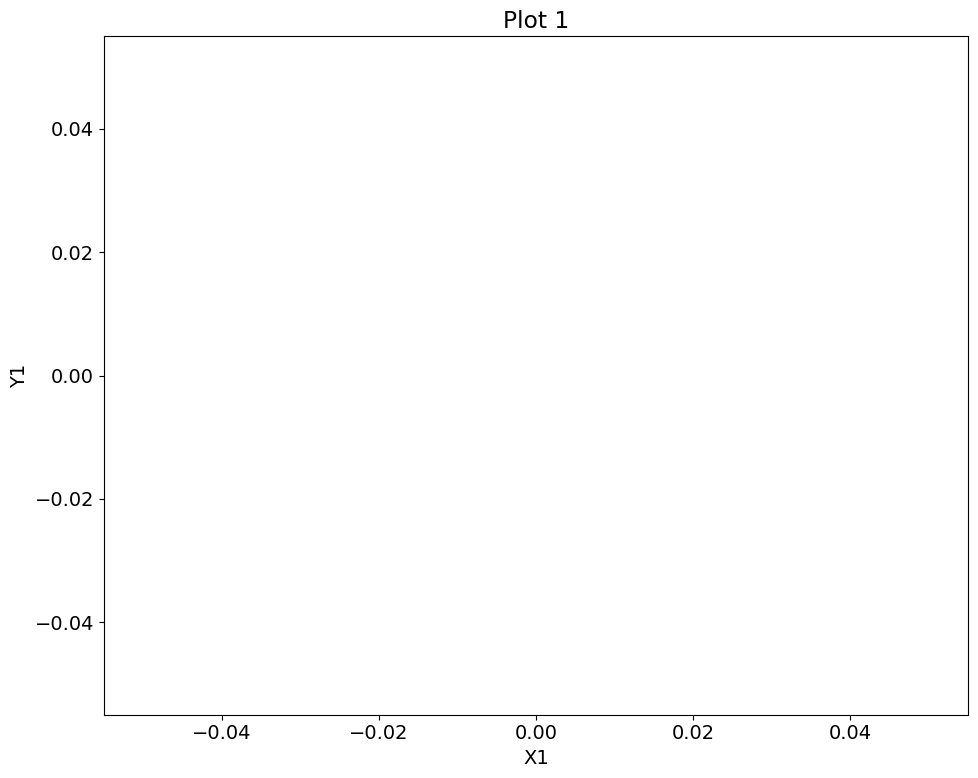

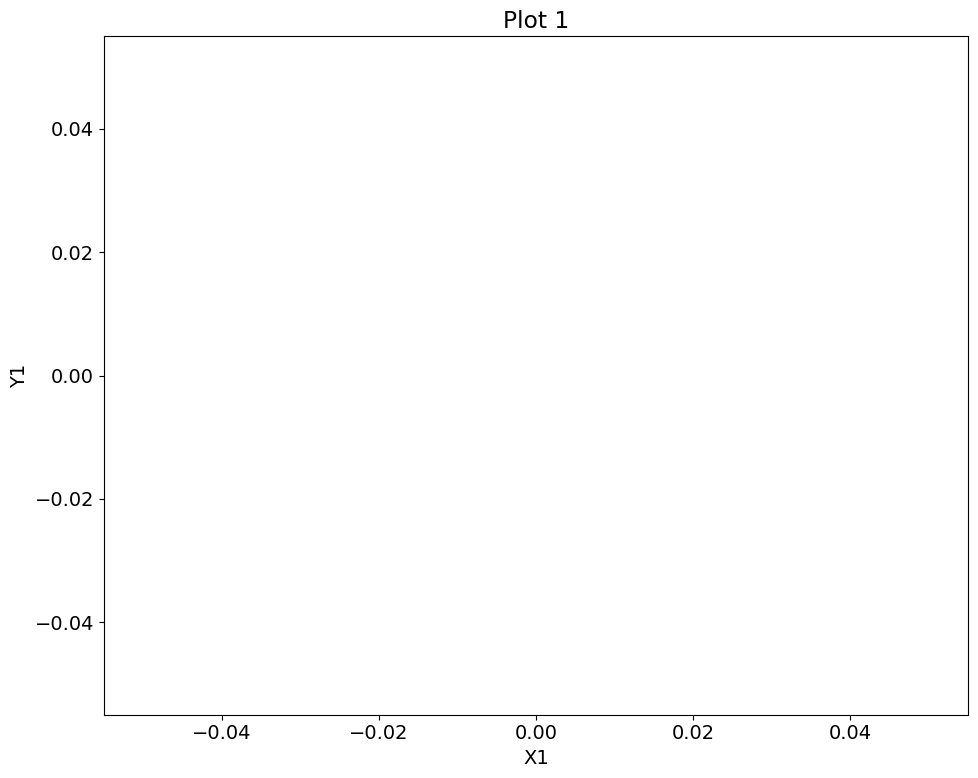

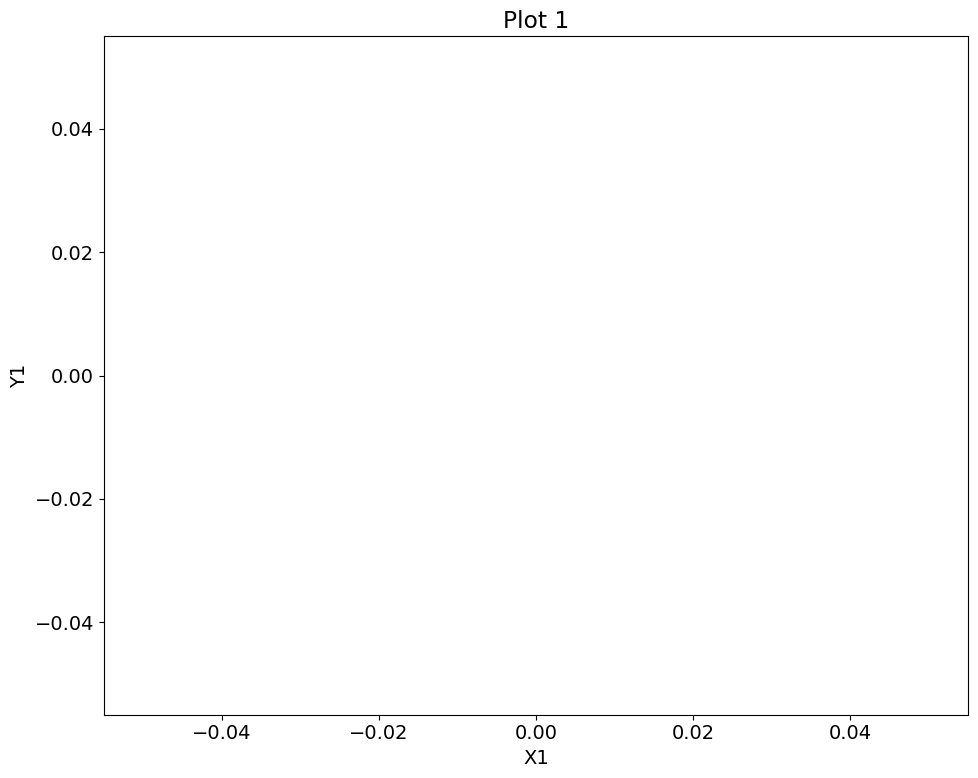

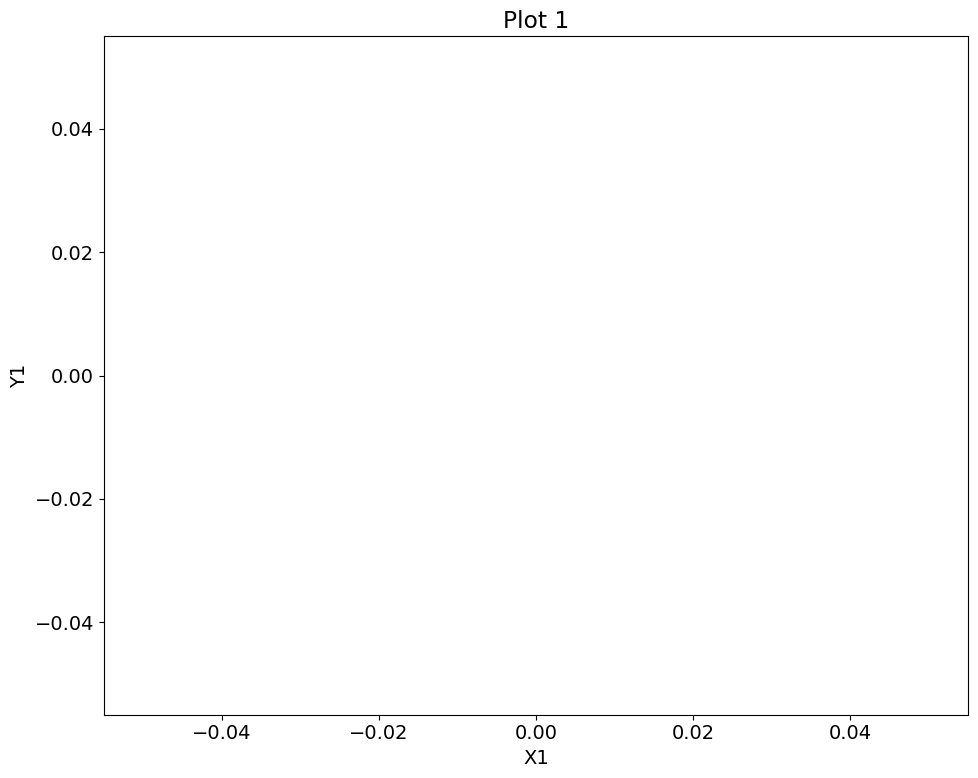

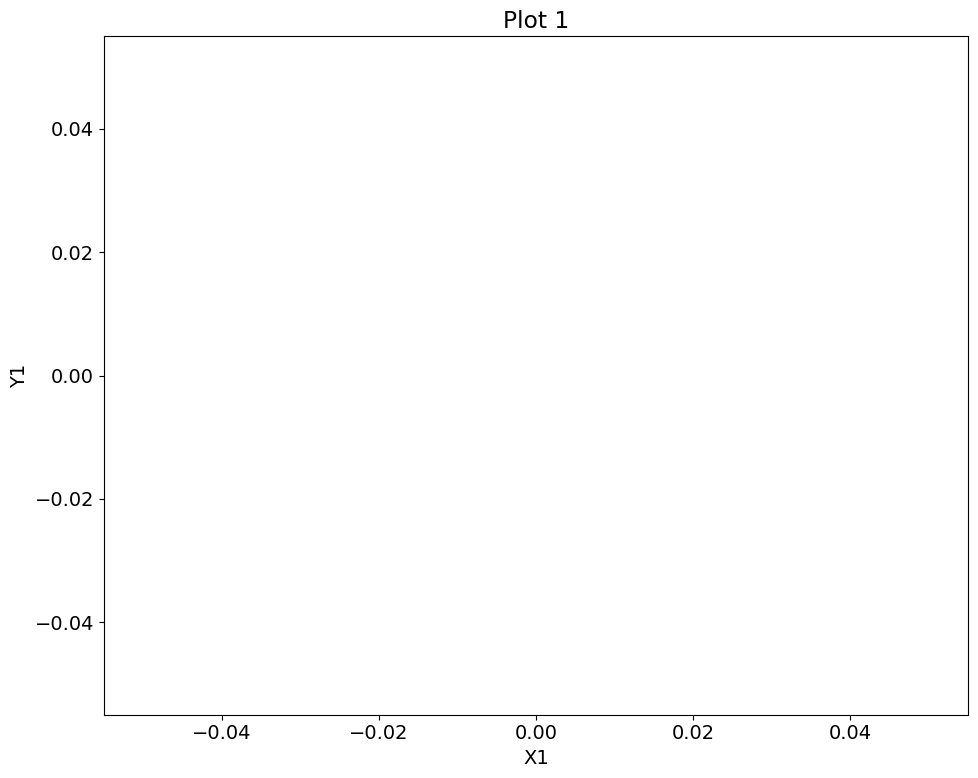

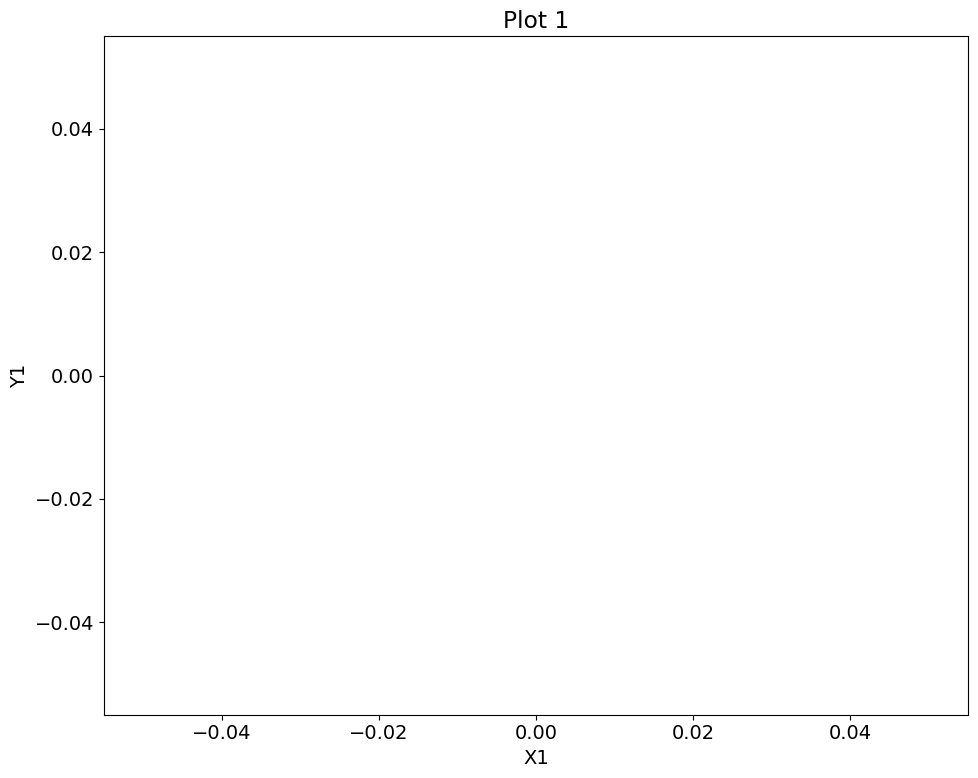

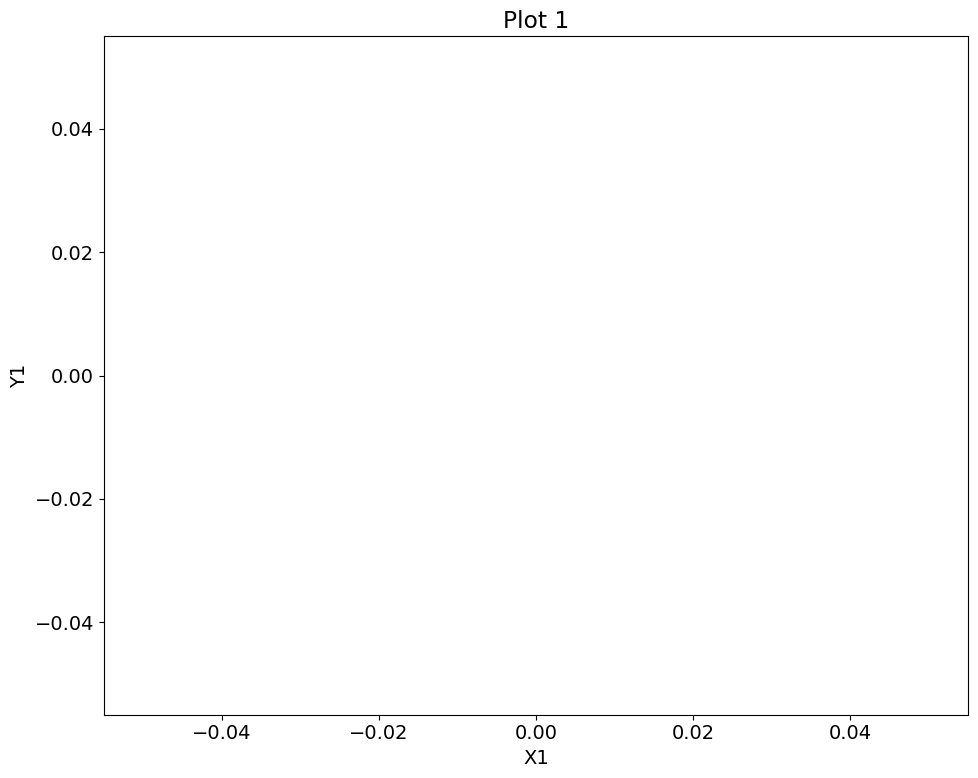

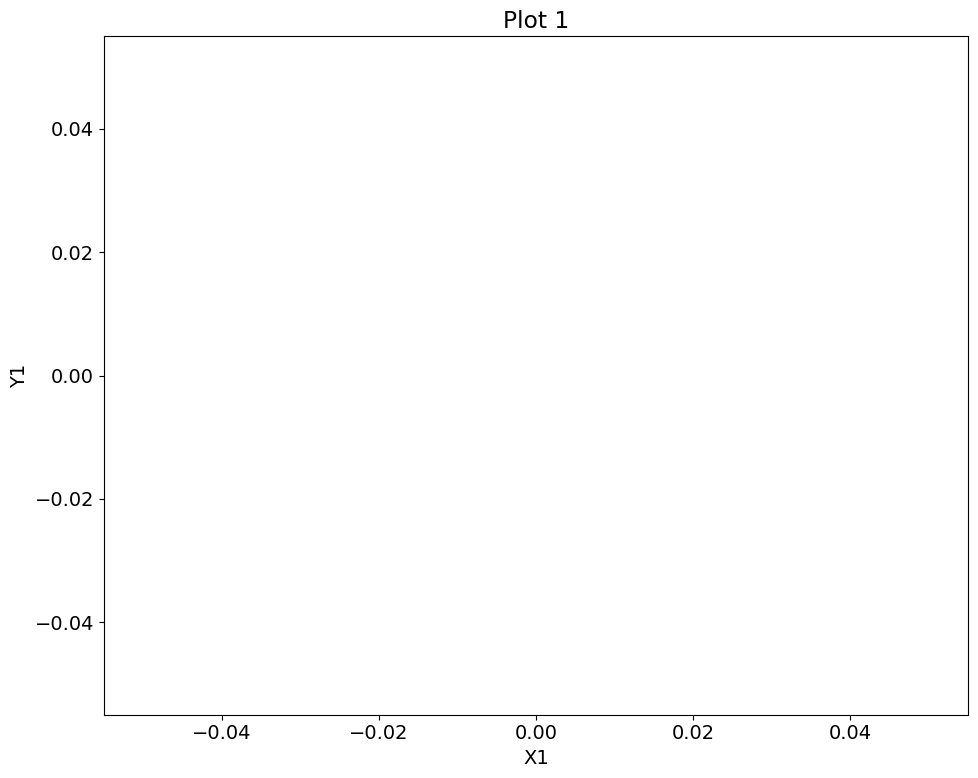

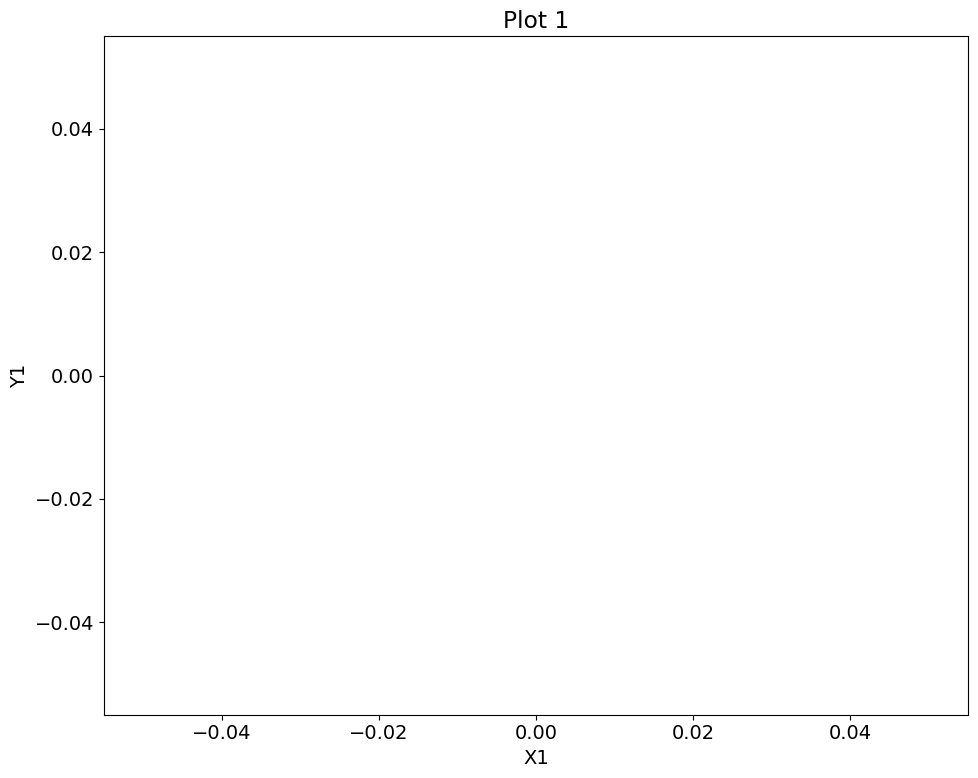

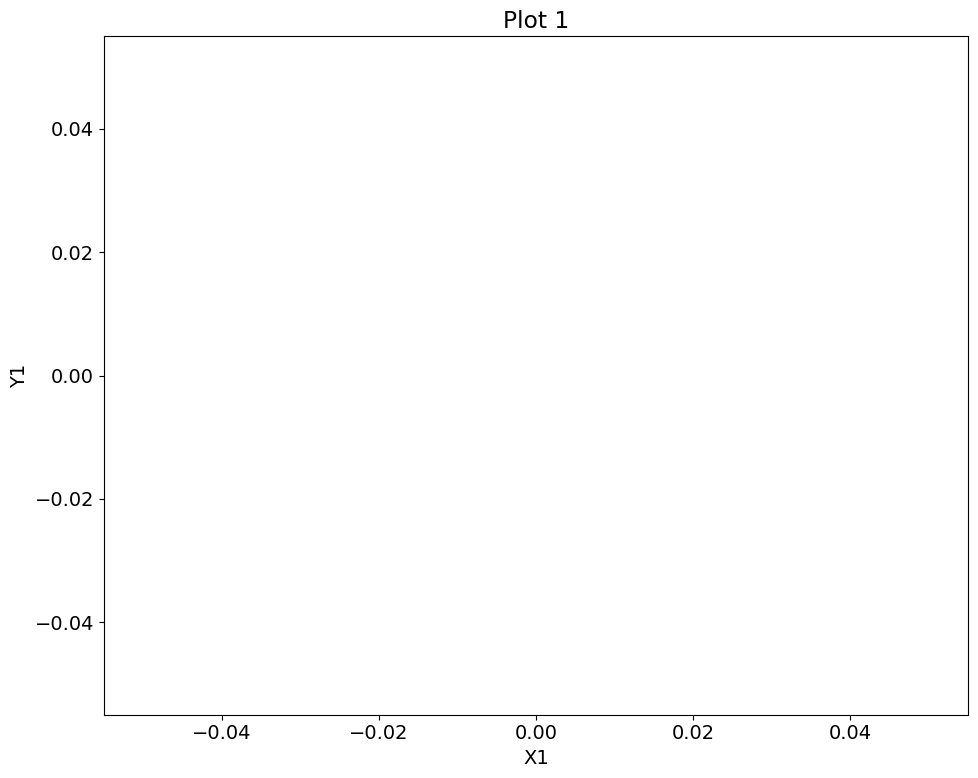

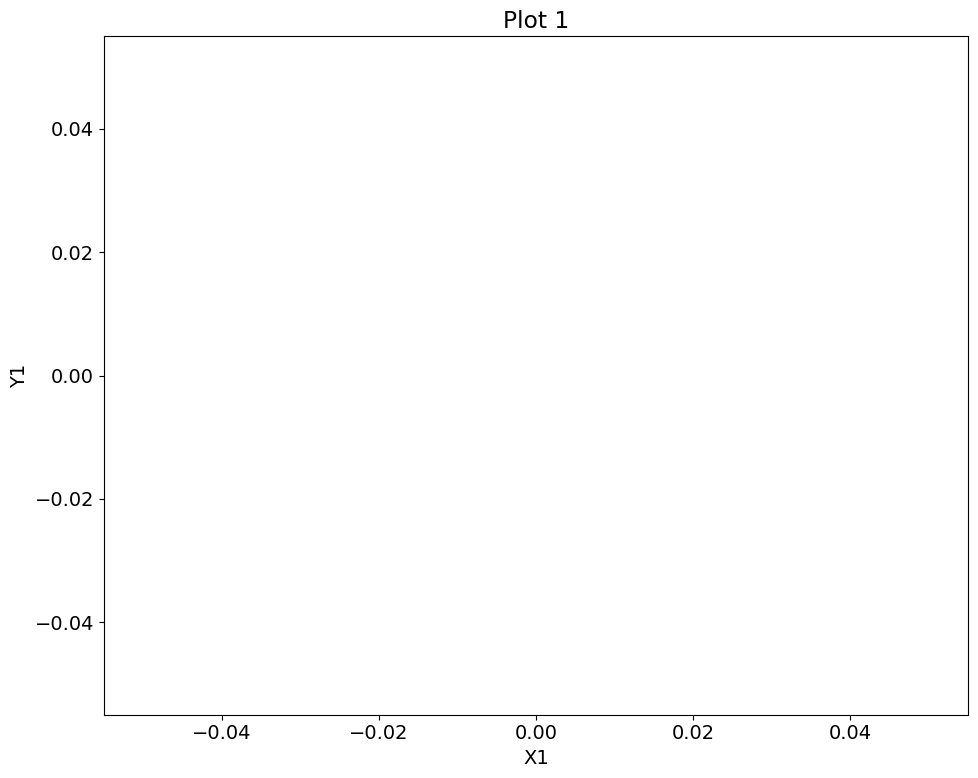

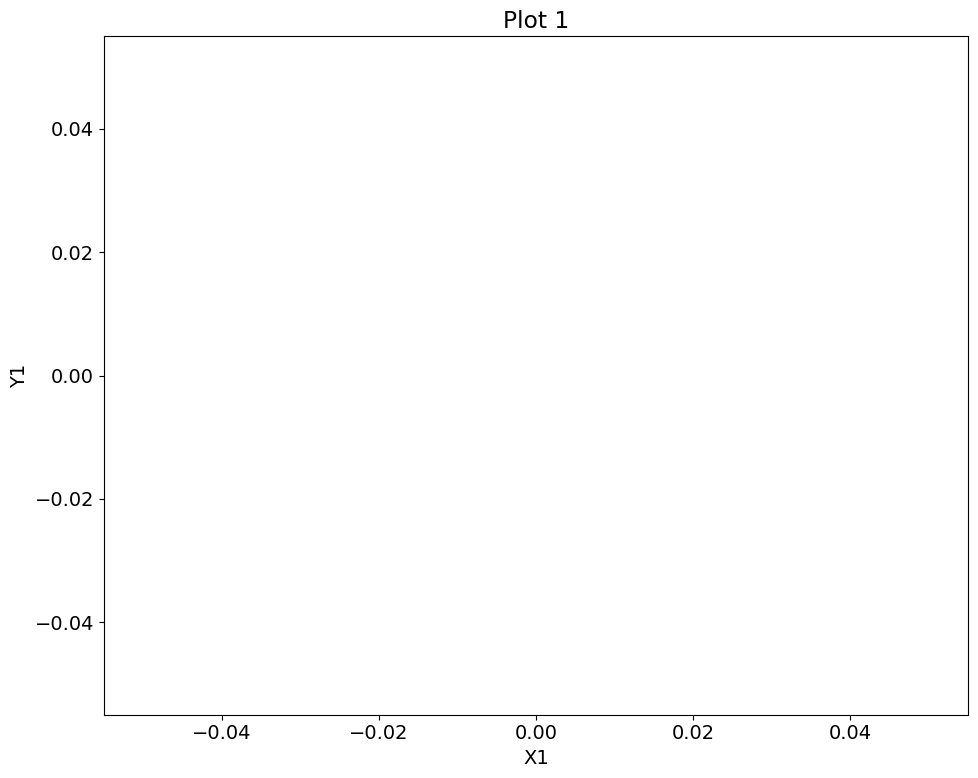

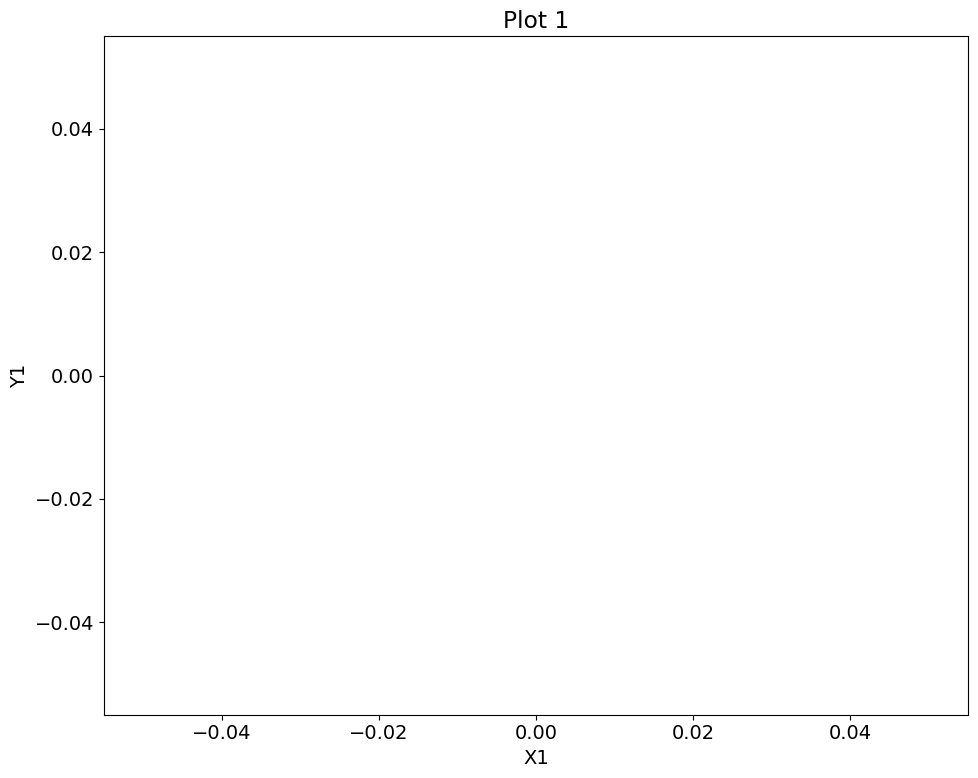

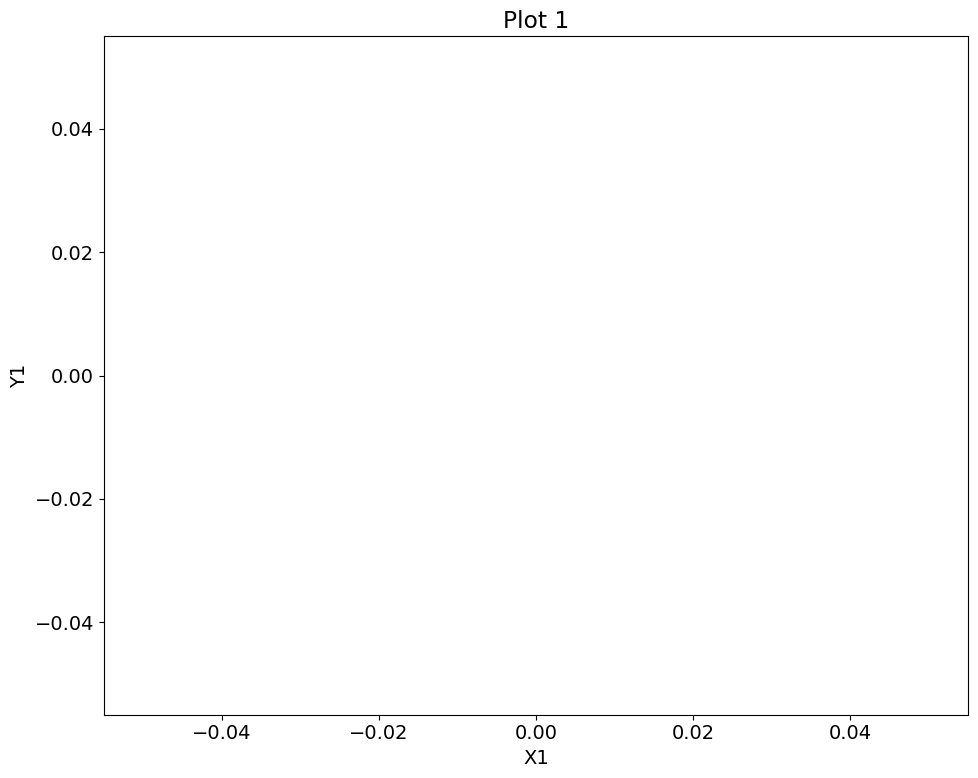

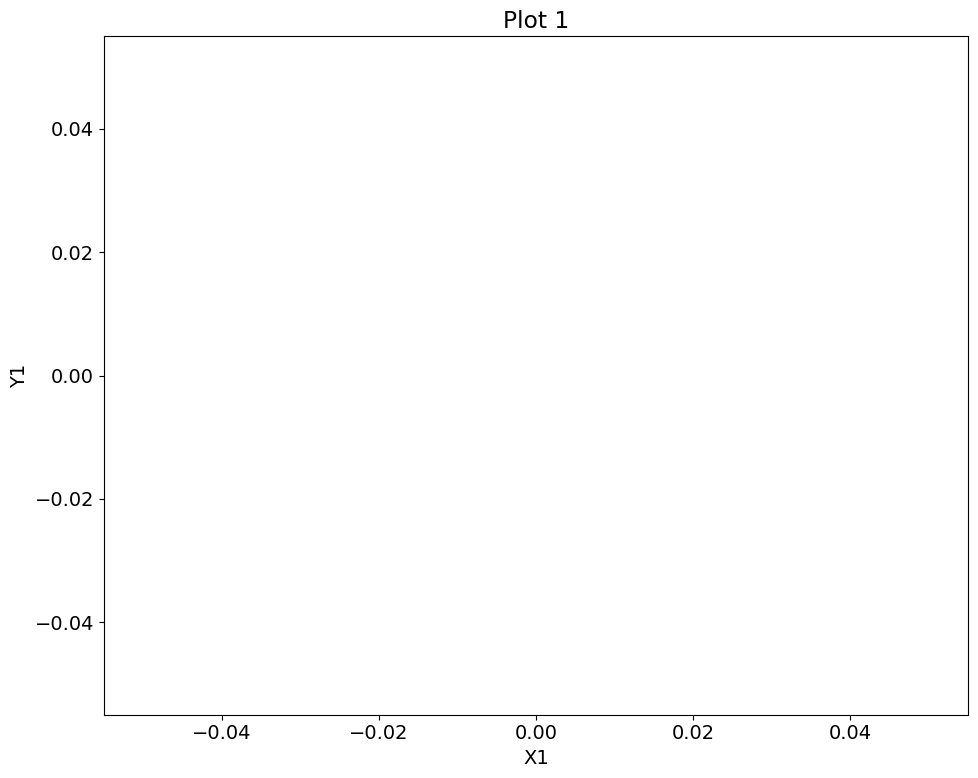

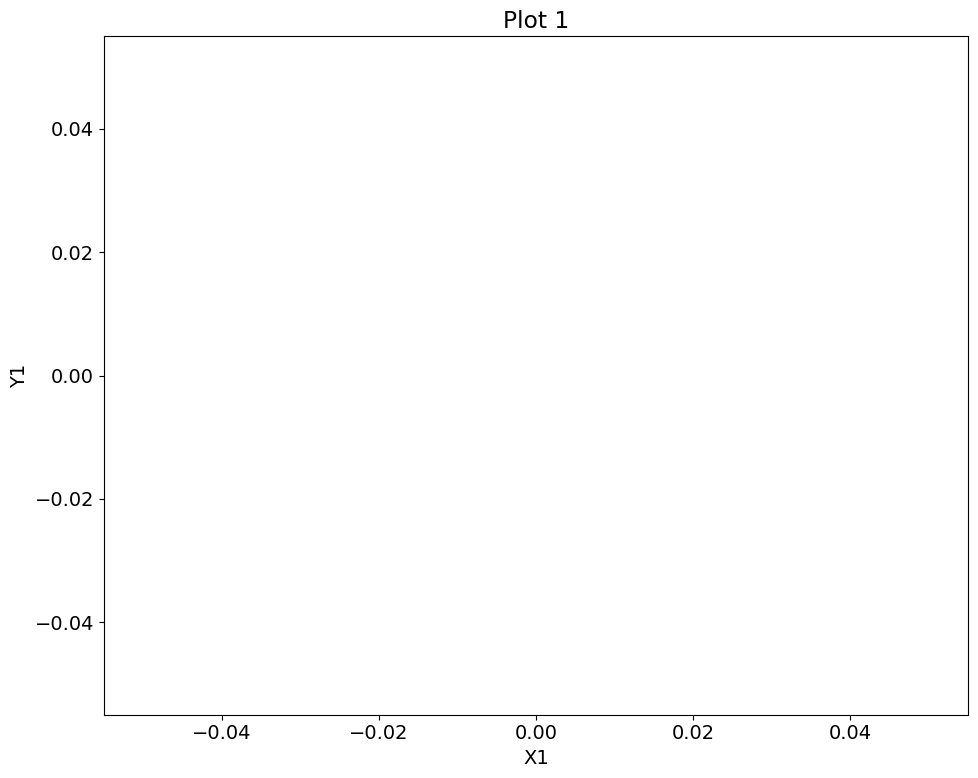

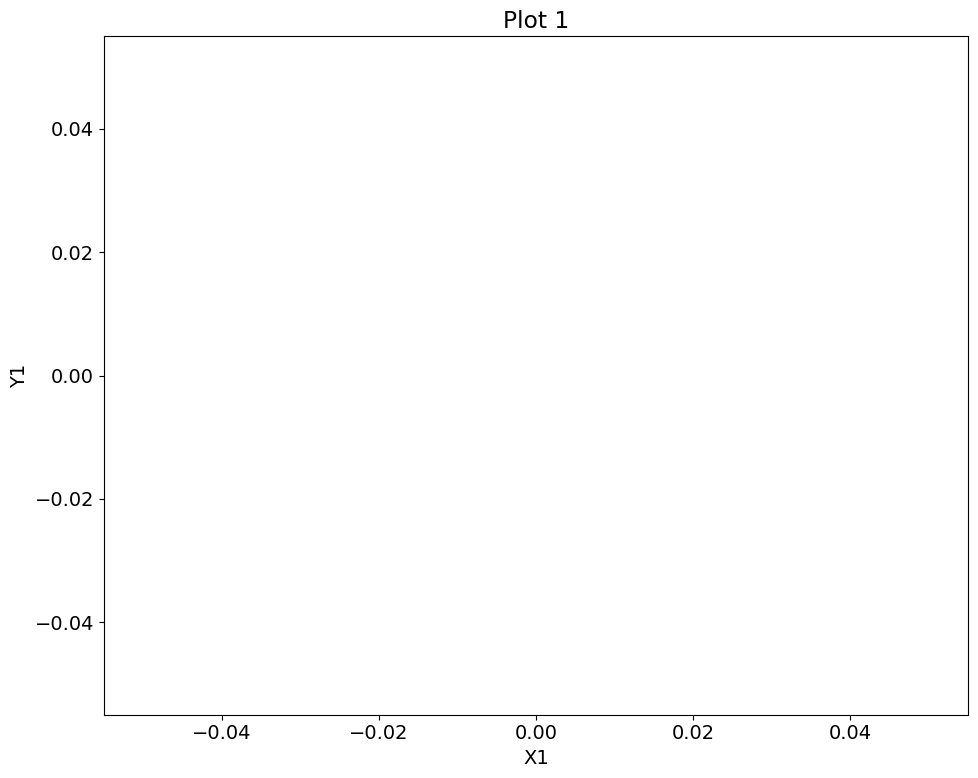

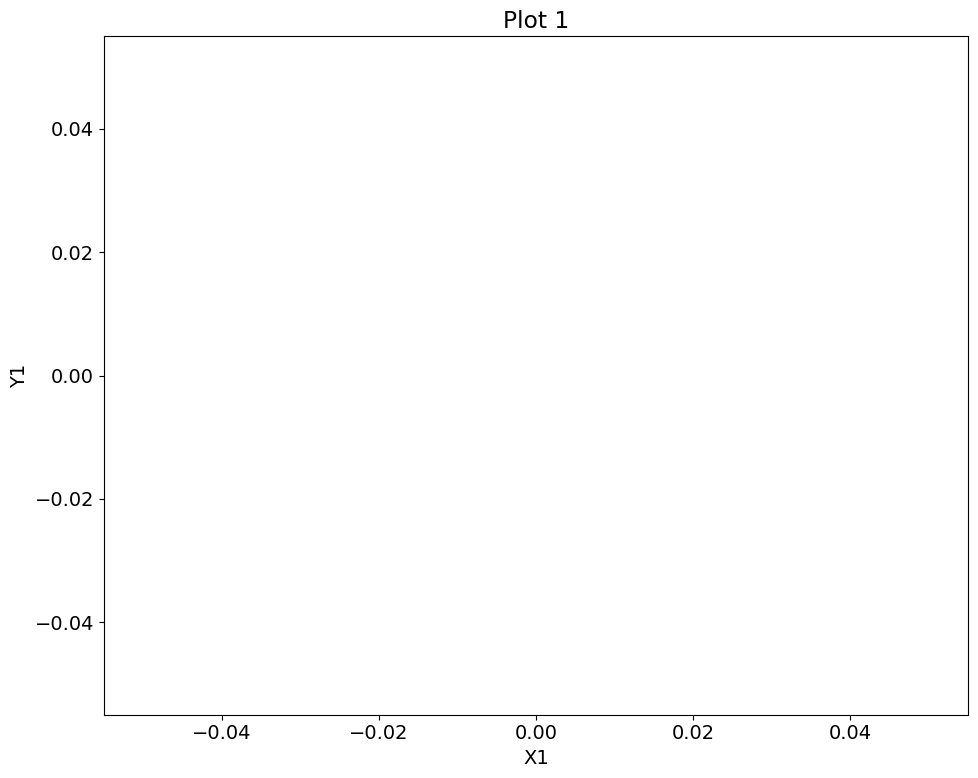

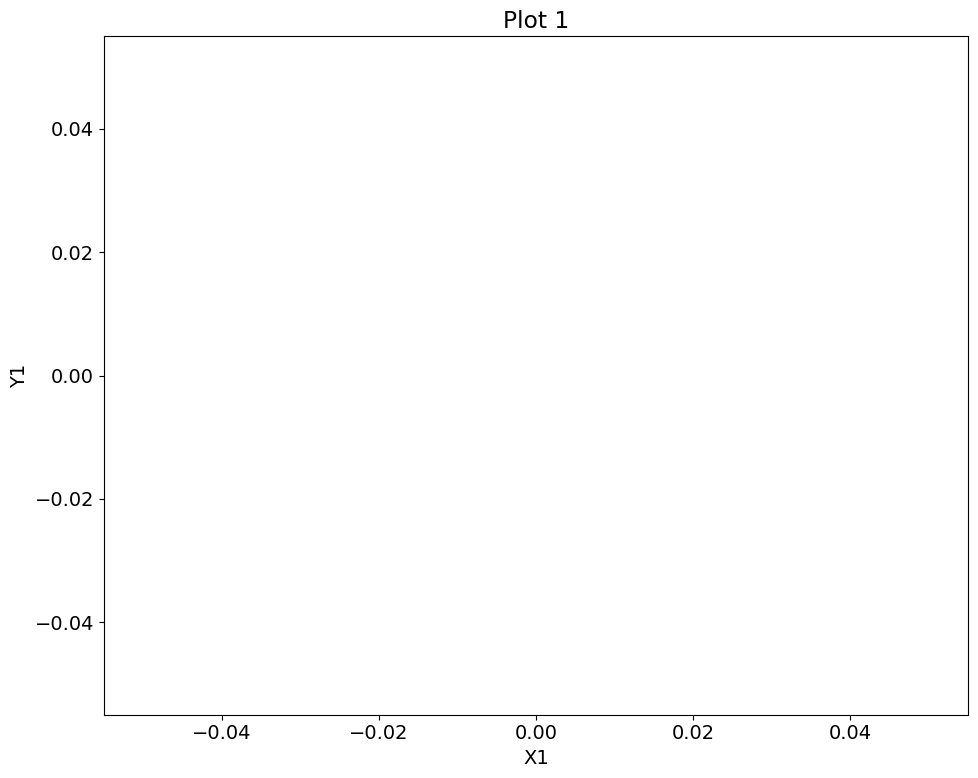

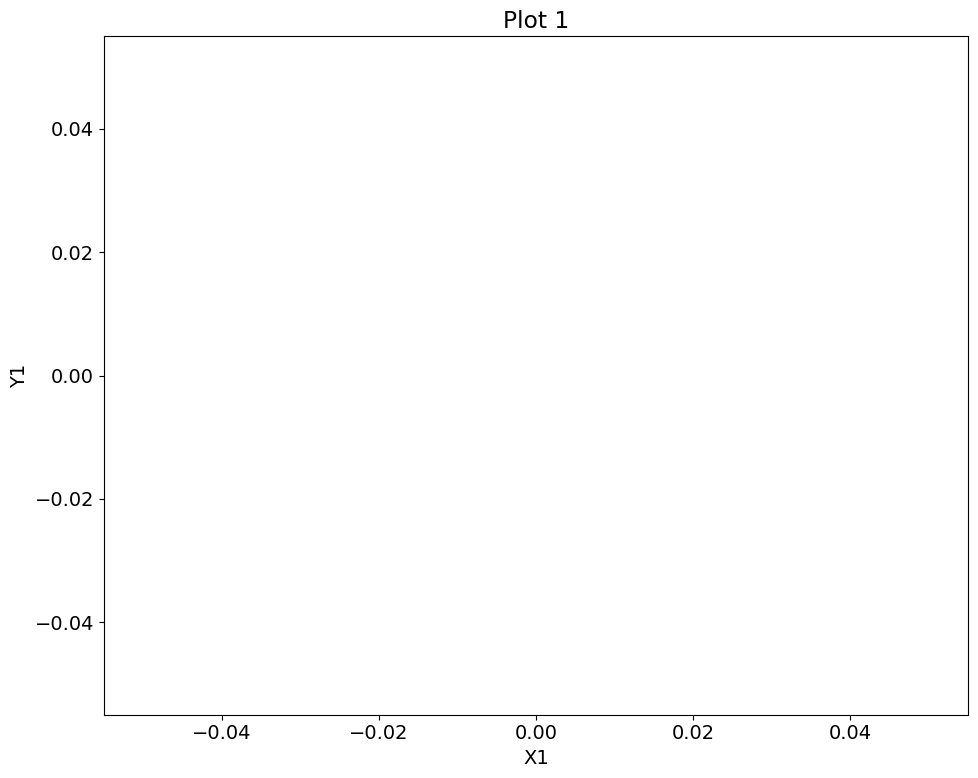

In [7]:
simulation_config_base_dict["ev_agent_type"] = "congestion_aware" # means CA
test = ['EV_DRL']


num_samples = 10  # each stategy is sample 10 times and evaluate?

for sim in tqdm(range(num_sim_config)):   # 1 based on above set balue
    
    simulation_config_base_dict["num_ev_agents"] = num_ev_agents[sim]
    simulation_config_base_dict["num_nf_agents"] = num_nf_agents[sim]
    simulation_config_base_dict["pv_area"] = pv_areas[sim]
    simulation_config_base_dict["congestion_limit"] = congestion_limits[sim]
    if num_ev_agents[sim] > 480:
        num_samples = 2
    for strategy in tqdm(test, leave=False, desc="Strategies"):
        for sample in tqdm(range(num_samples), leave=False, desc="Samples"):
            simulation_config_base_dict["strategy_name"] = strategy
            simulation_config_base_dict["seed"] = sample
            full_path = base_path + f"CA/EVs_{num_ev_agents[sim]}/" + strategy + "/" + str(sample) + "/"
            simulation_config_base_dict["path"] = full_path
            simulation_config = SimulationConfig(**simulation_config_base_dict)
            simulation = Simulation(simulation_config)
            results = simulation.run()

print("Test CA Done!")

In [4]:
simulation_config_base_dict["ev_agent_type"] = "congestion_aware" # means CA
# decentralized_strategies_ca =["GREEDY" "FTPL-IRS-EXP","FTPL-IRS-F2","Inde-TS"]
decentralized_strategies_ca =[ "Inde-TS"]

num_samples = 10  # each stategy is sample 10 times and evaluate?

for sim in tqdm(range(num_sim_config)):   # 1 based on above set balue
    
    simulation_config_base_dict["num_ev_agents"] = num_ev_agents[sim]
    simulation_config_base_dict["num_nf_agents"] = num_nf_agents[sim]
    simulation_config_base_dict["pv_area"] = pv_areas[sim]
    simulation_config_base_dict["congestion_limit"] = congestion_limits[sim]
    if num_ev_agents[sim] > 480:
        num_samples = 2
    for strategy in tqdm(decentralized_strategies_ca, leave=False, desc="Strategies"):
        for sample in tqdm(range(num_samples), leave=False, desc="Samples"):
            simulation_config_base_dict["strategy_name"] = strategy
            simulation_config_base_dict["seed"] = sample
            full_path = base_path + f"CA/EVs_{num_ev_agents[sim]}/" + strategy + "/" + str(sample) + "/"
            simulation_config_base_dict["path"] = full_path
            simulation_config = SimulationConfig(**simulation_config_base_dict)
            simulation = Simulation(simulation_config)
            results = simulation.run()

print("Decentralized CA Done!")

  0%|          | 0/1 [00:00<?, ?it/s]

Strategies:   0%|          | 0/1 [00:00<?, ?it/s]

Samples:   0%|          | 0/10 [00:00<?, ?it/s]

Episodes:   0%|          | 0/1460 [00:00<?, ?it/s]

Episodes:   0%|          | 0/1460 [00:00<?, ?it/s]

...

Episodes:   0%|          | 0/1460 [00:00<?, ?it/s]

Episodes:   0%|          | 0/1460 [00:00<?, ?it/s]

Episodes:   0%|          | 0/1460 [00:00<?, ?it/s]

Episodes:   0%|          | 0/1460 [00:00<?, ?it/s]

Decentralized CA Done!


Decentralized Simulation (Price Based Loss L_1 EVs):

In [5]:
simulation_config_base_dict["ev_agent_type"] = "default"
decentralized_strategies = ["FTPL-IRS-EXP","FTPL-IRS-F2","Inde-TS","GREEDY"]

num_samples = 10

for sim in tqdm(range(num_sim_config)): # 1 simulation for 5 num of EV
    
    simulation_config_base_dict["num_ev_agents"] = num_ev_agents[sim]
    simulation_config_base_dict["num_nf_agents"] = num_nf_agents[sim]
    simulation_config_base_dict["pv_area"] = pv_areas[sim]
    simulation_config_base_dict["congestion_limit"] = congestion_limits[sim]
    if num_ev_agents[sim] > 480:
            num_samples = 2
    for strategy in tqdm(decentralized_strategies, leave=False, desc="Strategies"):
        
        for sample in tqdm(range(num_samples), leave=False, desc="Samples"):
            simulation_config_base_dict["strategy_name"] = strategy
            simulation_config_base_dict["seed"] = sample
            full_path = base_path + f"default/EVs_{num_ev_agents[sim]}/" + strategy + "/" + str(sample) + "/"
            simulation_config_base_dict["path"] = full_path
            simulation_config = SimulationConfig(**simulation_config_base_dict)
            simulation = Simulation(simulation_config)
            results = simulation.run()

print("Decentralized default Done!")

  0%|          | 0/1 [00:00<?, ?it/s]

Strategies:   0%|          | 0/4 [00:00<?, ?it/s]

Samples:   0%|          | 0/10 [00:00<?, ?it/s]

Episodes:   0%|          | 0/1460 [00:00<?, ?it/s]

Episodes:   0%|          | 0/1460 [00:00<?, ?it/s]

...

Episodes:   0%|          | 0/1460 [00:00<?, ?it/s]

Episodes:   0%|          | 0/1460 [00:00<?, ?it/s]

Episodes:   0%|          | 0/1460 [00:00<?, ?it/s]

Episodes:   0%|          | 0/1460 [00:00<?, ?it/s]

Decentralized default Done!


Centralized Simulation (Price Based Loss L_2 EVs):

In [6]:
simulation_config_base_dict["ev_agent_type"] = "congestion_aware"

num_samples = 10
centralized_strategies_ca = ["MILP_Price_Forecast"]

for sim in tqdm(range(num_sim_config),leave = False, desc = "Simulation"):
    
    simulation_config_base_dict["num_ev_agents"] = num_ev_agents[sim]
    simulation_config_base_dict["num_nf_agents"] = num_nf_agents[sim]
    simulation_config_base_dict["pv_area"] = pv_areas[sim]
    simulation_config_base_dict["congestion_limit"] = congestion_limits[sim]
    if num_ev_agents[sim] > 480:
        num_samples = 0
    for strategy in tqdm(centralized_strategies_ca, leave=False, desc="Strategies"):
        for sample in tqdm(range(num_samples), leave=False, desc="Samples"):
            simulation_config_base_dict["strategy_name"] = strategy
            simulation_config_base_dict["seed"] = sample
            full_path = base_path + f"CA/EVs_{num_ev_agents[sim]}/" + strategy + "/" + str(sample) + "/"
            simulation_config_base_dict["path"] = full_path
            simulation_config = SimulationConfig(**simulation_config_base_dict)
            simulation = Simulation(simulation_config)
            results = simulation.run()

print("Centralized default Done!")

Simulation:   0%|          | 0/1 [00:00<?, ?it/s]

Strategies:   0%|          | 0/1 [00:00<?, ?it/s]

Samples:   0%|          | 0/10 [00:00<?, ?it/s]

Episodes:   0%|          | 0/1460 [00:00<?, ?it/s]

Episodes:   0%|          | 0/1460 [00:00<?, ?it/s]

...

Episodes:   0%|          | 0/1460 [00:00<?, ?it/s]

Episodes:   0%|          | 0/1460 [00:00<?, ?it/s]

Episodes:   0%|          | 0/1460 [00:00<?, ?it/s]

Episodes:   0%|          | 0/1460 [00:00<?, ?it/s]

Centralized default Done!
